In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_cleaned.csv')

In [3]:
df.head()

,age,income,home_ownership,emp_length,loan_intent,loan_grade,loan_amount,interest_rate,loan_status,loan_to_income,prev_default,credit_hist_length,loan_status_label,age_group,income_group,loan_group,loan_risk,interest_rate_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,No,2,Non-Default,20-25,Low,Small,Low Risk,Medium
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,No,3,Default,20-25,Low,Small,Medium Risk,High
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,No,2,Default,20-25,Medium,Very Large,Medium Risk,High
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Default,20-25,Medium,Very Large,Medium Risk,High
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,No,2,Default,20-25,Low,Small,Low Risk,Low


### Univariate:

#### 1. What is the overall default rate?

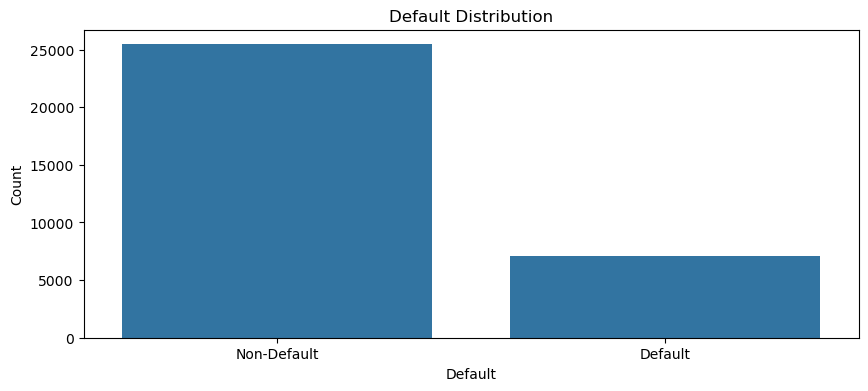

In [4]:
plt.figure(figsize = (10,4))
plt.title('Default Distribution')
sns.countplot(df, x = 'loan_status_label')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()


In [5]:
df['loan_status_label'].value_counts(normalize=True)*100

loan_status_label
Non-Default    78.178077
Default        21.821923
Name: proportion, dtype: float64

**Insight:** Approximatly 21.8% of loan applicants defaulted, while 78.2% successfully repaid. This indicates a class imbalance in the datasets, similar to churn analysis.

#### 2. What is the age distribution of loan applicants?

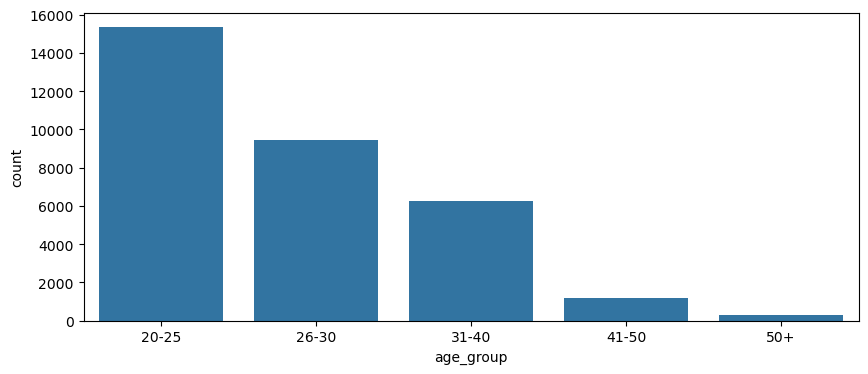

In [6]:
plt.figure(figsize=(10,4))
sns.countplot(df, x='age_group')
plt.show()

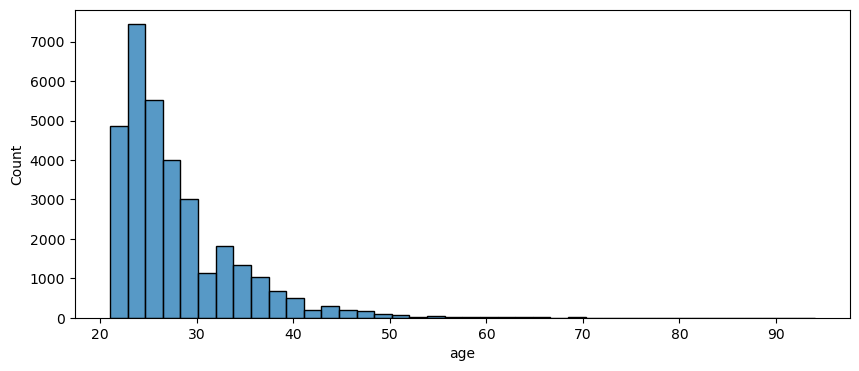

In [7]:
plt.figure(figsize=(10,4))
sns.histplot(df, x='age', bins=40)
plt.show()

In [8]:
df['age_group'].value_counts(normalize=True)*100

age_group
20-25    47.099112
26-30    29.091803
31-40    19.235849
41-50     3.704045
50+       0.869191
Name: proportion, dtype: float64

**Insight:** Majority of loan applicants are young 47.1% are aged 20-25, followed by 26-30 (29.1%). This suggests that the dataset is dominated by young borrowers, possibly students or early career professionals.

#### 3. What is the distribution of loan amounts?

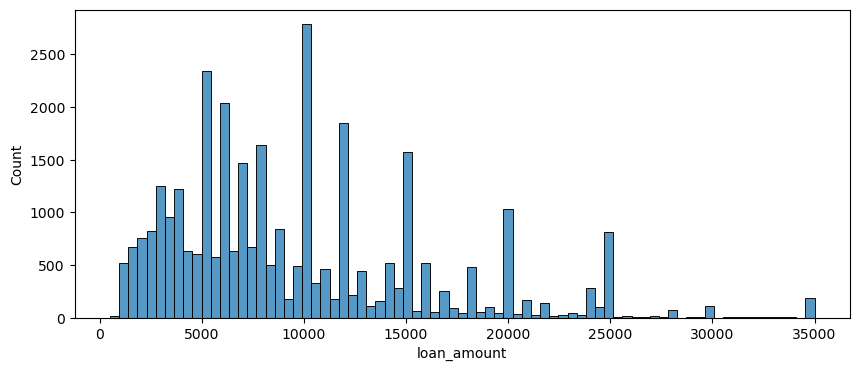

In [9]:
plt.figure(figsize=(10,4))
sns.histplot(df, x = 'loan_amount')
plt.show()

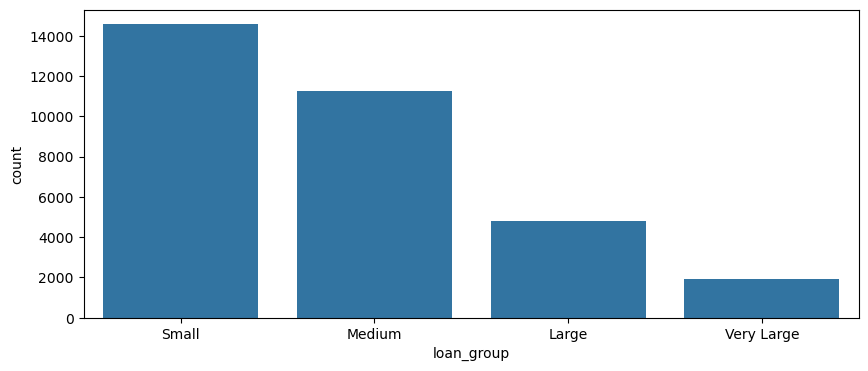

In [10]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'loan_group', order=['Small','Medium','Large','Very Large'])
plt.show()

In [11]:
df['loan_group'].value_counts(normalize=True)*100

loan_group
Small         44.749532
Medium        34.617157
Large         14.699469
Very Large     5.933843
Name: proportion, dtype: float64

**Insight:** Majority of loans are Small (44.8%) and Medium (34.6%). Very Large are rare (5.9%), suggesting most applicants borrow relatively modest amount.

#### 4. What is the distribution of interest rates?

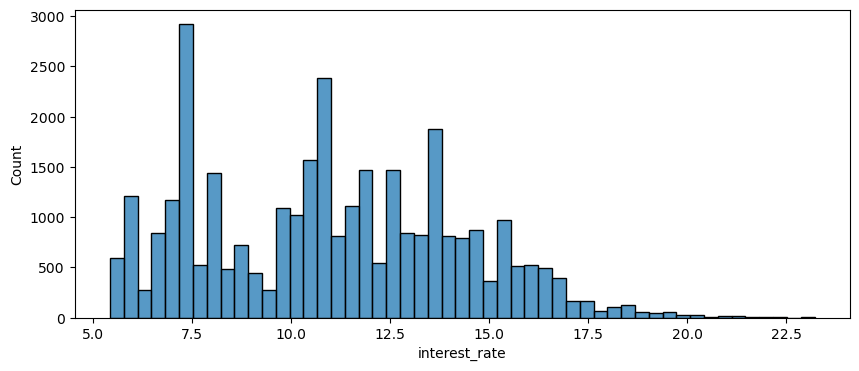

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df, x = 'interest_rate')
plt.show()

**Insight:** Interest rate distribution is multimodal with peaks around 7.5%, 10.5%, and 13.5%. This suggests different loan grades have distinct interest rate ranges. Most loans fall between 7-15% interest rate.

#### 5. What is the breakdown of loan intent?

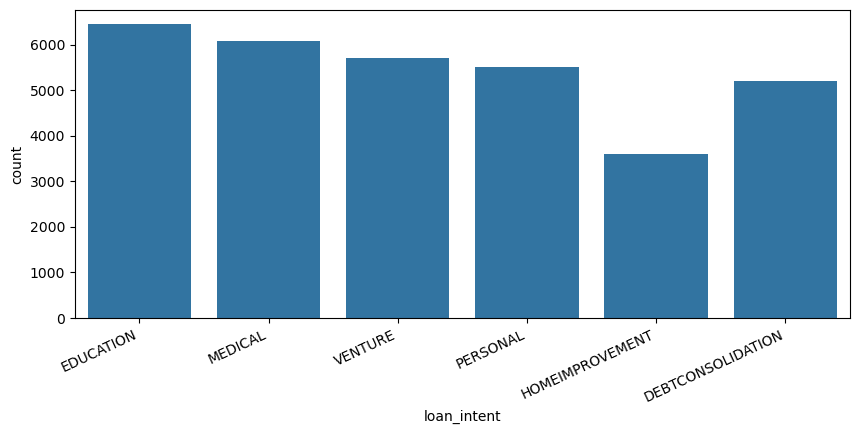

In [13]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'loan_intent')
plt.xticks(rotation = 25, ha = 'right')
plt.show()

In [14]:
df['loan_intent'].value_counts(normalize=True)*100

loan_intent
EDUCATION            19.797905
MEDICAL              18.643079
VENTURE              17.540465
PERSONAL             16.944624
DEBTCONSOLIDATION    16.001720
HOMEIMPROVEMENT      11.072207
Name: proportion, dtype: float64

**Insight:** Loan intent is fairly evenly distributed. Education (19.8%) and Medical (18.6%) on the top reasons for borrowing followed by Vnture (17.6%) and Personal (16.9%). Home Improvemnt has the lowest share(11.1%)

#### 6. What is the breakdown of home ownership?

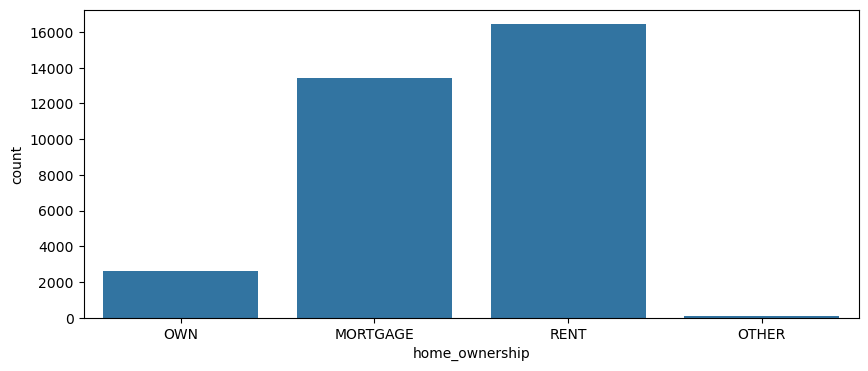

In [15]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'home_ownership')
plt.show()

In [16]:
df['home_ownership'].value_counts(normalize=True)*100

home_ownership
RENT        50.486809
MORTGAGE    41.248196
OWN          7.936362
OTHER        0.328634
Name: proportion, dtype: float64

**Insight:** Half of all applicants are renters (50.5%), followed by mortgage holders (41.3%). Only 7.9% own their home outright. This suggests most of applicants do not have strong asset backing for their loans.

#### 7. What is the breakdown of loan grade?

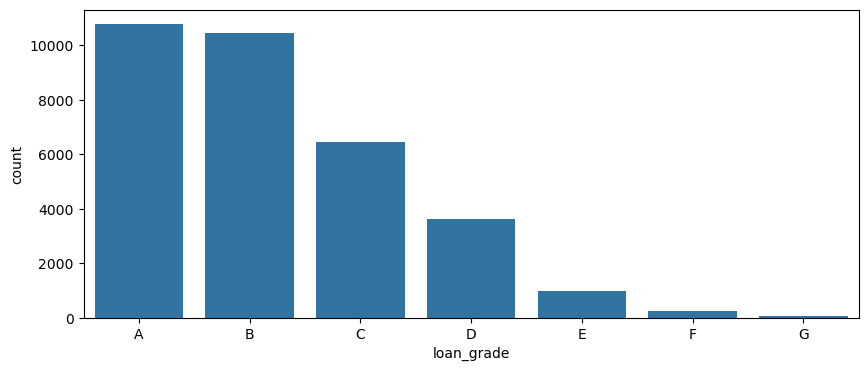

In [17]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'loan_grade', order=['A','B','C','D','E','F','G'])
plt.show()

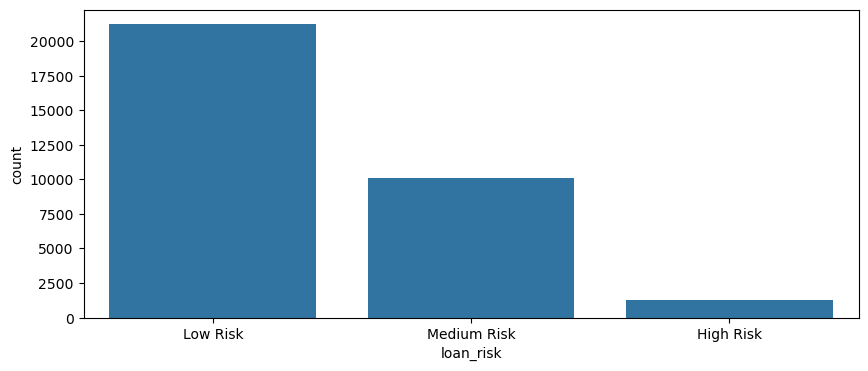

In [18]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'loan_risk')
plt.show()

In [19]:
df['loan_grade'].value_counts(normalize=True)*100

loan_grade
A    33.084554
B    32.074081
C    19.822476
D    11.121349
E     2.960779
F     0.740195
G     0.196566
Name: proportion, dtype: float64

**Insight:** Majority of loans are Grade A (33.1%) and Grade B (32.1%), indicating most applicants have good creditworthiness. High risk Grade E, F, G combined only 3.9% - very few applicants fall in the extreme risk category.

### Bivariate:
#### 8. Which loan intent has the highest default rate?

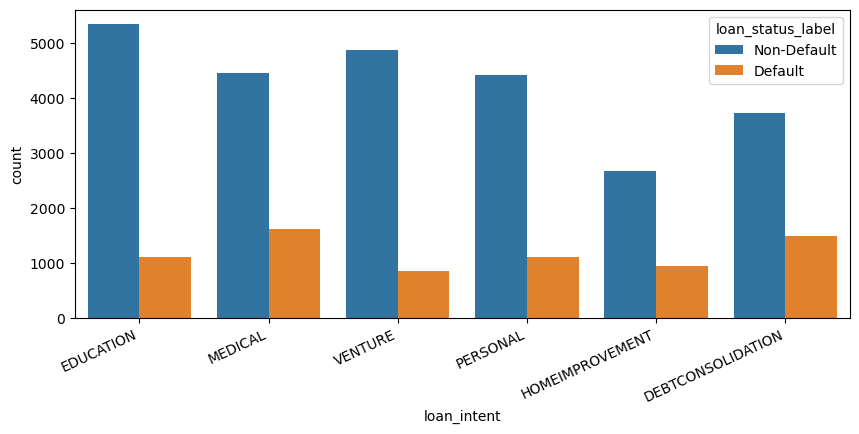

In [20]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'loan_intent', hue = 'loan_status_label')
plt.xticks(rotation = 25, ha = 'right')
plt.show()

In [21]:
df.groupby('loan_intent')['loan_status'].mean()*100

loan_intent
DEBTCONSOLIDATION    28.598848
EDUCATION            17.235495
HOMEIMPROVEMENT      26.102635
MEDICAL              26.705107
PERSONAL             19.865869
VENTURE              14.813518
Name: loan_status, dtype: float64

**Insight:** Debt Consolidation loans have the highest default rate (28.6%), followed by Medical (26.7%) and Home Improvement (26.1%). Venture lonas have the lowest default rate (14.8%), suggesting business oriented borrows are more financially disciplined.

#### 9. Which loan grade has the highest default rate?

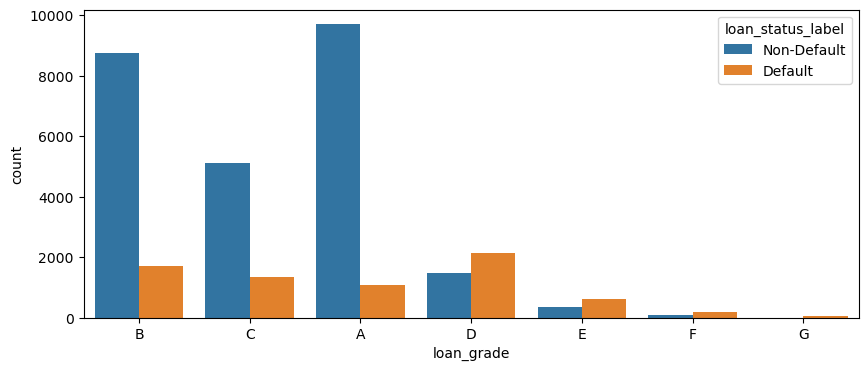

In [22]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'loan_grade', hue = 'loan_status_label')
plt.show()

In [23]:
df.groupby('loan_grade')['loan_status'].mean()*100

loan_grade
A     9.961010
B    16.288423
C    20.746824
D    59.044463
E    64.419087
F    70.539419
G    98.437500
Name: loan_status, dtype: float64

**Insight:** Default rate increase dramatically with loan grade. Grade A has only 9.9% deafault rate whiel Grade G has 98.4% - almost certain default. This confirms laon grade is the strongest predictor of default risk. Grade D, E, F, G should be considered extremely high risk.

#### 10. Does home ownership affect default rate?

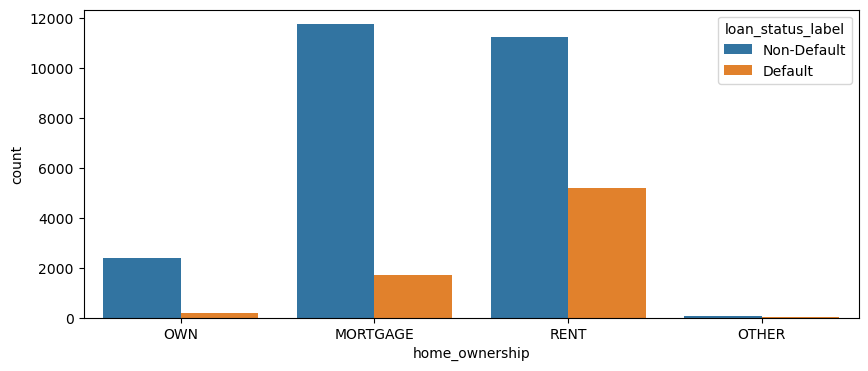

In [24]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'home_ownership', hue = 'loan_status_label')
plt.show()

In [25]:
df.groupby('home_ownership')['loan_status'].mean()*100

home_ownership
MORTGAGE    12.576322
OTHER       30.841121
OWN          7.469040
RENT        31.573184
Name: loan_status, dtype: float64

**Insight:** Renters has the highest default rate (31.6%), followed by Other (30.8%). Home Owners have the lowest default rate (7.5%). Suggesting that owning a home indicates better financial stability and lower credit risk.

#### 11. Which age group defaults the most?

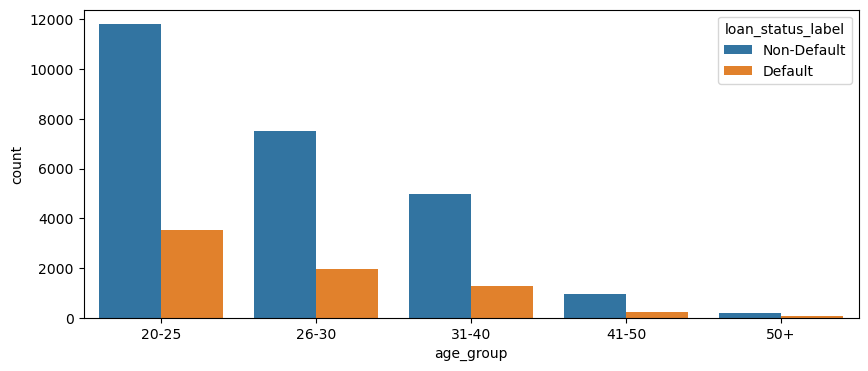

In [26]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'age_group', hue = 'loan_status_label')
plt.show()

In [27]:
df.groupby('age_group')['loan_status'].mean()*100

age_group
20-25    23.032279
26-30    20.882601
31-40    20.373623
41-50    20.398010
50+      25.795053
Name: loan_status, dtype: float64

**Insight:** Default rate is fairly consistent across age group (20-25%). Youngest (20-25) and oldest (50+) borrowers default slightly more. However, since 76% of applicants are under 30, younger borrowers represents majority of actual default.

#### 12. Which income group defaults the most?

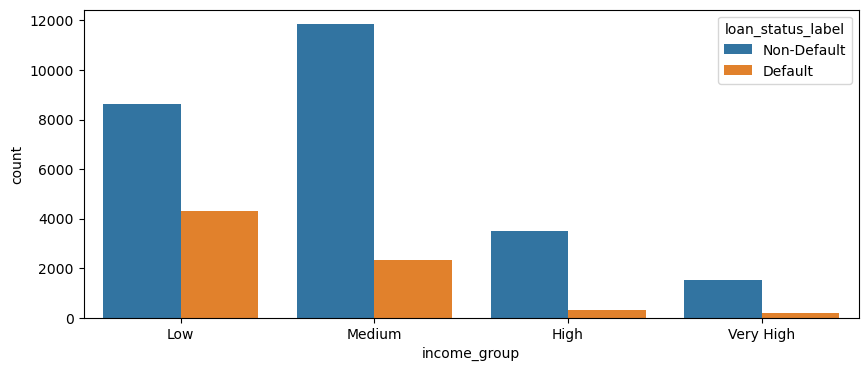

In [28]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'income_group', hue = 'loan_status_label')
plt.show()

In [29]:
df.groupby('income_group')['loan_status'].mean()*100

income_group
High          8.483896
Low          33.237667
Medium       16.404431
Very High    10.208955
Name: loan_status, dtype: float64

**Insight:** Low income applicants have the highest default rate (33.2%), which is 4x higher than the high income applicants (8.5%). Income is a strong predictor of default risk - lower income borrowers stugle significantly more to repay loans. 

#### 13. Which loan amount group defaults the most?

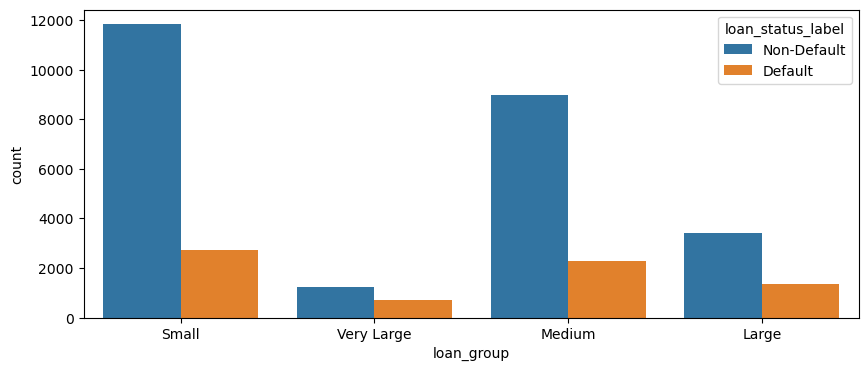

In [30]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'loan_group', hue = 'loan_status_label')
plt.show()

In [31]:
df.groupby('loan_group')['loan_status'].mean()*100

loan_group
Large         28.687840
Medium        20.361991
Small         18.805765
Very Large    36.076605
Name: loan_status, dtype: float64

**Insight:** Very Large loans have the highest default rate (36%), followed by Large loan (28.7%). Small loans default the least (18.8%). This suggests borrowers taking large loans may be overextending their financial capacity.

#### 14. Does previous default history affect current default rate?

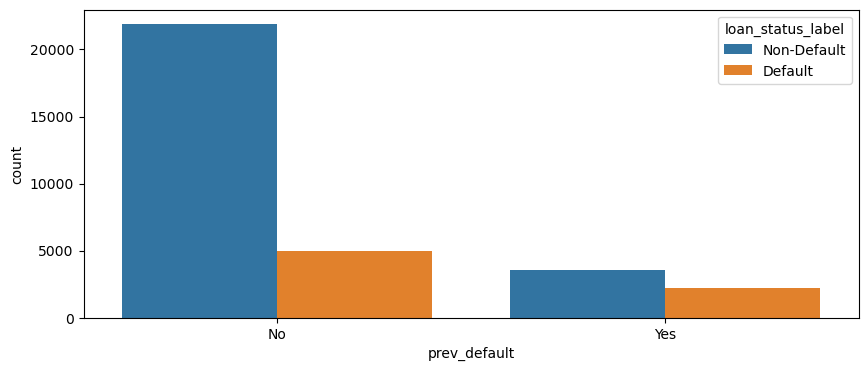

In [32]:
plt.figure(figsize=(10,4))
sns.countplot(df, x = 'prev_default', hue = 'loan_status_label')
plt.show()

In [33]:
df.groupby('prev_default')['loan_status'].mean()*100

prev_default
No     18.401820
Yes    37.798293
Name: loan_status, dtype: float64

**Insight:** Applicants with a previous default history are twice as likely to default again (37.8% vs 18.4%). Previous default is a strong indicator of future risk bank should exercise extra caution with these applicants.

#### 15. Does loan risk group affect default rate?

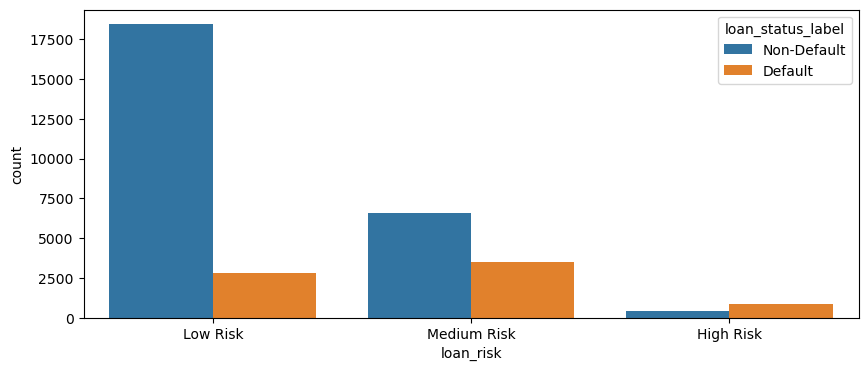

In [34]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'loan_risk', hue = 'loan_status_label')
plt.show()

In [35]:
df.groupby('loan_risk')['loan_status'].mean()*100

loan_risk
High Risk      67.297084
Low Risk       13.075654
Medium Risk    34.511166
Name: loan_status, dtype: float64

**Insight:** High Risk loans(Grade E,F,G) have a staggering 67.3% default rate, comapared to only 13.1% for Low Risk loans. Medium Risk sits at 34.5%. Loan risk group is clearly one of the strongest predictor of default behavior.

### Correlation:
#### 16. How are numeric features correlated with loan status?

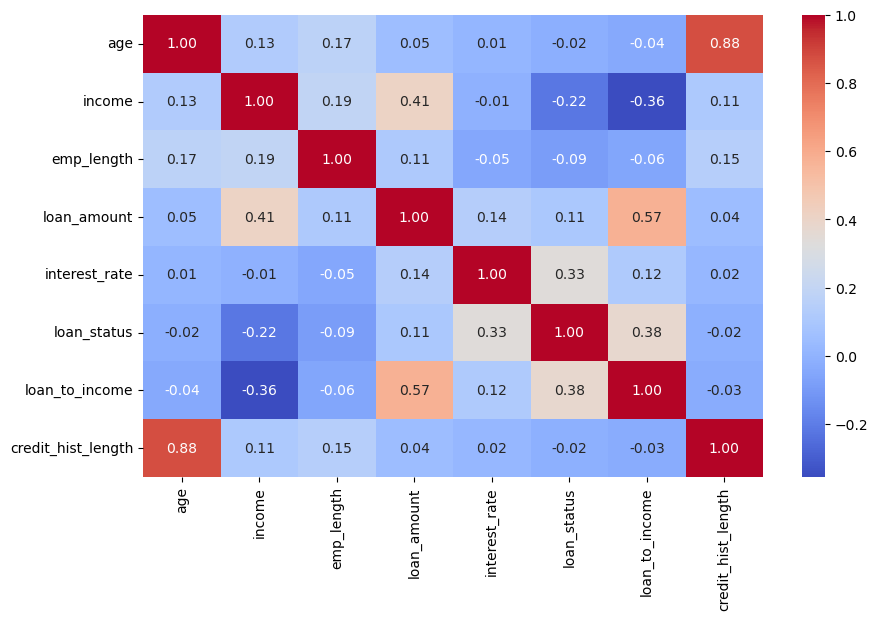

In [36]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize = (10,6))
sns.heatmap(numeric_df.corr(), annot = True,
           fmt = '.2f',
           cmap = 'coolwarm')
plt.show()

**Insight:** 
- Interest rate has the stongest positive correlation with loan status (0.33) - higher interest = more default.
- Loan to income ratio also strongly correlated (0.38) - borrowing more relative to income on increases default risk.
- Income has negative correlation with loan status (-0.22) - higher income = less default.
- Age and credit_hist_length are highly correlated (0.88) - older people naturally have longer credit history.
- Loan amount and loan to income are correlated (0.57) - larger loans take up more of income.